<a href="https://colab.research.google.com/github/Moquiuti/fundamentos-ia-investigando-algoritmos-abordagens-machine-learning/blob/main/identificando_objetos_com_MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

In [2]:
modelo = MobileNetV2(weights='imagenet')
print("Modelo carregado com sucesso.")

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Modelo carregado com sucesso.


In [3]:
uploaded = files.upload()

Saving Image (8).jpg to Image (8).jpg


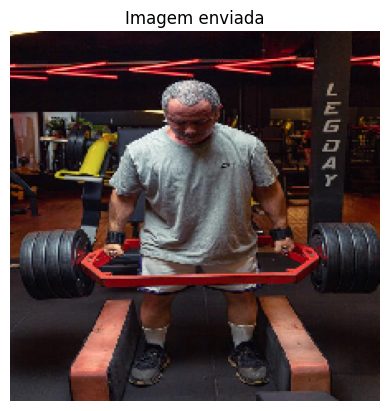

In [4]:
nome_arquivo = list(uploaded.keys())[0]

img = image.load_img(nome_arquivo, target_size=(224, 224))
img_array = image.img_to_array(img)

plt.imshow(img)
plt.axis('off')
plt.title("Imagem enviada")
plt.show()

In [5]:
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

In [6]:
predicoes = modelo.predict(img_array)
resultado = decode_predictions(predicoes, top=3)[0]

print("Principais previsões:")
for i, (codigo, classe, probabilidade) in enumerate(resultado, 1):
    print(f"{i}. {classe} - {probabilidade:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Principais previsões:
1. barbell - 66.79%
2. dumbbell - 13.51%
3. tricycle - 2.97%


In [7]:
classe_principal = resultado[0][1]
confianca = resultado[0][2]

print(f"\nClasse identificada: {classe_principal}")
print(f"Confiança da predição: {confianca:.2%}")


Classe identificada: barbell
Confiança da predição: 66.79%
